<a href="https://colab.research.google.com/github/Khansuhai/Building-detection-Automation-/blob/main/indiashapefilesindiapresp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1: INSTALL LIBRARIES
# ============================================================
!pip install geopandas matplotlib -q
print("✅ Done")

✅ Done


In [2]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
import shutil
from google.colab import files, drive

print("✅ All Libraries Imported")

✅ All Libraries Imported


In [3]:
# ============================================================
# CELL 3: MOUNT GOOGLE DRIVE
# ============================================================
drive.mount('/content/drive')

# CREATE OUTPUT FOLDER IN DRIVE
out = '/content/drive/MyDrive/WESTERN_HIMALAYA_SHAPEFILES/'
os.makedirs(out, exist_ok=True)

print("✅ Google Drive Mounted")
print(f"📁 Output Folder: {out}")

Mounted at /content/drive
✅ Google Drive Mounted
📁 Output Folder: /content/drive/MyDrive/WESTERN_HIMALAYA_SHAPEFILES/


In [4]:
# ============================================================
# CELL 4: UPLOAD YOUR INDIA SHAPEFILE
# SELECT ALL 4 FILES TOGETHER:
# India_State_Boundary.shp
# India_State_Boundary.shx
# India_State_Boundary.dbf
# India_State_Boundary.prj
# HOLD CTRL + CLICK ALL 4 → UPLOAD
# ============================================================
print("Please upload all 4 files together:")
print("→ India_State_Boundary.shp")
print("→ India_State_Boundary.shx")
print("→ India_State_Boundary.dbf")
print("→ India_State_Boundary.prj")
print("\nHold CTRL and select all 4 files\n")

uploaded = files.upload()

print("\nFiles uploaded:")
for f in uploaded.keys():
    print(f"  ✅ {f}")

Please upload all 4 files together:
→ India_State_Boundary.shp
→ India_State_Boundary.shx
→ India_State_Boundary.dbf
→ India_State_Boundary.prj

Hold CTRL and select all 4 files



Saving India_State_Boundary.cpg to India_State_Boundary.cpg
Saving India_State_Boundary.dbf to India_State_Boundary.dbf
Saving India_State_Boundary.prj to India_State_Boundary.prj
Saving India_State_Boundary.sbn to India_State_Boundary.sbn
Saving India_State_Boundary.sbx to India_State_Boundary.sbx
Saving India_State_Boundary.shp to India_State_Boundary.shp
Saving India_State_Boundary.shx to India_State_Boundary.shx

Files uploaded:
  ✅ India_State_Boundary.cpg
  ✅ India_State_Boundary.dbf
  ✅ India_State_Boundary.prj
  ✅ India_State_Boundary.sbn
  ✅ India_State_Boundary.sbx
  ✅ India_State_Boundary.shp
  ✅ India_State_Boundary.shx


In [5]:
# ============================================================
# CELL 5: LOAD SHAPEFILE + CHECK COLUMNS
# ============================================================
india = gpd.read_file('India_State_Boundary.shp')

print("="*55)
print("INDIA SHAPEFILE LOADED SUCCESSFULLY")
print("="*55)
print(f"Total States/UTs : {len(india)}")
print(f"CRS              : {india.crs}")
print(f"\nCOLUMN NAMES:")
for col in india.columns:
    print(f"  → {col}")

INDIA SHAPEFILE LOADED SUCCESSFULLY
Total States/UTs : 36
CRS              : EPSG:4326

COLUMN NAMES:
  → Name
  → Type
  → geometry


In [6]:
# ============================================================
# CELL 6: CHECK ALL STATE NAMES
# READ THIS OUTPUT CAREFULLY
# NOTE THE EXACT SPELLING OF:
# Ladakh / Jammu & Kashmir / Himachal Pradesh
# ============================================================
print("="*55)
print("ALL STATE/UT NAMES IN YOUR FILE:")
print("="*55)

for col in india.columns:
    if col != 'geometry':
        print(f"\nColumn → '{col}'")
        print("-"*40)
        for val in sorted(india[col].dropna().unique()):
            print(f"  '{val}'")

ALL STATE/UT NAMES IN YOUR FILE:

Column → 'Name'
----------------------------------------
  'Andaman & Nicobar'
  'Andhra Pradesh'
  'Arunachal Pradesh'
  'Assam'
  'Bihar'
  'Chandigarh'
  'Chhattishgarh'
  'Daman and Diu and Dadra and Nagar Haveli'
  'Delhi'
  'Goa'
  'Gujarat'
  'Haryana'
  'Himachal Pradesh'
  'Jammu and Kashmir'
  'Jharkhand'
  'Karnataka'
  'Kerala'
  'Ladakh'
  'Lakshadweep'
  'Madhya Pradesh'
  'Maharashtra'
  'Manipur'
  'Meghalaya'
  'Mizoram'
  'Nagaland'
  'Odisha'
  'Puducherry'
  'Punjab'
  'Rajasthan'
  'Sikkim'
  'Tamilnadu'
  'Telengana'
  'Tripura'
  'Uttar Pradesh'
  'Uttarakhand'
  'West Bengal'

Column → 'Type'
----------------------------------------
  'State'
  'Union Territory'


In [7]:
# ============================================================
# CELL 7: AUTO DETECT NAME COLUMN
# ============================================================
name_col = None

search_words = ['ladakh', 'kashmir',
                'himachal', 'punjab',
                'gujarat', 'maharashtra']

for col in india.columns:
    if col != 'geometry':
        vals = india[col].astype(str).str.lower()
        if any(vals.str.contains(w).any()
               for w in search_words):
            name_col = col
            print(f"✅ Name Column Found: '{name_col}'")
            break

if name_col is None:
    name_col = 'NAME_1'
    print(f"⚠️ Auto detect failed")
    print(f"Using default: '{name_col}'")
    print(f"Change manually if wrong")

print(f"\nAll values in '{name_col}':")
for v in sorted(india[name_col].dropna().unique()):
    print(f"  → '{v}'")

✅ Name Column Found: 'Name'

All values in 'Name':
  → 'Andaman & Nicobar'
  → 'Andhra Pradesh'
  → 'Arunachal Pradesh'
  → 'Assam'
  → 'Bihar'
  → 'Chandigarh'
  → 'Chhattishgarh'
  → 'Daman and Diu and Dadra and Nagar Haveli'
  → 'Delhi'
  → 'Goa'
  → 'Gujarat'
  → 'Haryana'
  → 'Himachal Pradesh'
  → 'Jammu and Kashmir'
  → 'Jharkhand'
  → 'Karnataka'
  → 'Kerala'
  → 'Ladakh'
  → 'Lakshadweep'
  → 'Madhya Pradesh'
  → 'Maharashtra'
  → 'Manipur'
  → 'Meghalaya'
  → 'Mizoram'
  → 'Nagaland'
  → 'Odisha'
  → 'Puducherry'
  → 'Punjab'
  → 'Rajasthan'
  → 'Sikkim'
  → 'Tamilnadu'
  → 'Telengana'
  → 'Tripura'
  → 'Uttar Pradesh'
  → 'Uttarakhand'
  → 'West Bengal'


In [8]:
# ============================================================
# CELL 8: EXTRACT LADAKH + J&K + HIMACHAL PRADESH
# ============================================================

# ---- LADAKH ----
ladakh = india[
    india[name_col].str.contains(
        'Ladakh',
        case=False,
        na=False
    )
].copy().to_crs('EPSG:4326')

# ---- JAMMU & KASHMIR ----
jk = india[
    india[name_col].str.contains(
        'Jammu|Kashmir|J&K|Jammu & Kashmir',
        case=False,
        na=False
    )
].copy().to_crs('EPSG:4326')

# ---- HIMACHAL PRADESH ----
hp = india[
    india[name_col].str.contains(
        'Himachal|Himachal Pradesh',
        case=False,
        na=False
    )
].copy().to_crs('EPSG:4326')

# ============================================================
# CHECK RESULTS
# ============================================================
print("="*55)
print("EXTRACTION RESULTS")
print("="*55)

# LADAKH
print(f"\n1. LADAKH")
print(f"   Features found : {len(ladakh)}")
if len(ladakh) > 0:
    area_l = (ladakh.to_crs('EPSG:32643')
              .geometry.area.sum()/1e6)
    print(f"   Area           : {area_l:.0f} km²")
    print(f"   Status         : ✅ EXTRACTED")
else:
    print(f"   Status         : ❌ NOT FOUND")
    print(f"   ACTION         : Check spelling in Cell 6")

# J&K
print(f"\n2. JAMMU & KASHMIR")
print(f"   Features found : {len(jk)}")
if len(jk) > 0:
    area_jk = (jk.to_crs('EPSG:32643')
               .geometry.area.sum()/1e6)
    print(f"   Area           : {area_jk:.0f} km²")
    print(f"   Status         : ✅ EXTRACTED")
else:
    print(f"   Status         : ❌ NOT FOUND")
    print(f"   ACTION         : Check spelling in Cell 6")

# HIMACHAL
print(f"\n3. HIMACHAL PRADESH")
print(f"   Features found : {len(hp)}")
if len(hp) > 0:
    area_hp = (hp.to_crs('EPSG:32643')
               .geometry.area.sum()/1e6)
    print(f"   Area           : {area_hp:.0f} km²")
    print(f"   Status         : ✅ EXTRACTED")
else:
    print(f"   Status         : ❌ NOT FOUND")
    print(f"   ACTION         : Check spelling in Cell 6")

EXTRACTION RESULTS

1. LADAKH
   Features found : 1
   Area           : 166978 km²
   Status         : ✅ EXTRACTED

2. JAMMU & KASHMIR
   Features found : 1
   Area           : 57584 km²
   Status         : ✅ EXTRACTED

3. HIMACHAL PRADESH
   Features found : 1
   Area           : 55687 km²
   Status         : ✅ EXTRACTED


/tmp/ipykernel_831/2310472222.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx = ladakh.geometry.centroid.x.values[0]
/tmp/ipykernel_831/2310472222.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cy = ladakh.geometry.centroid.y.values[0]
/tmp/ipykernel_831/2310472222.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx = jk.geometry.centroid.x.values[0]
/tmp/ipykernel_831/2310472222.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before t

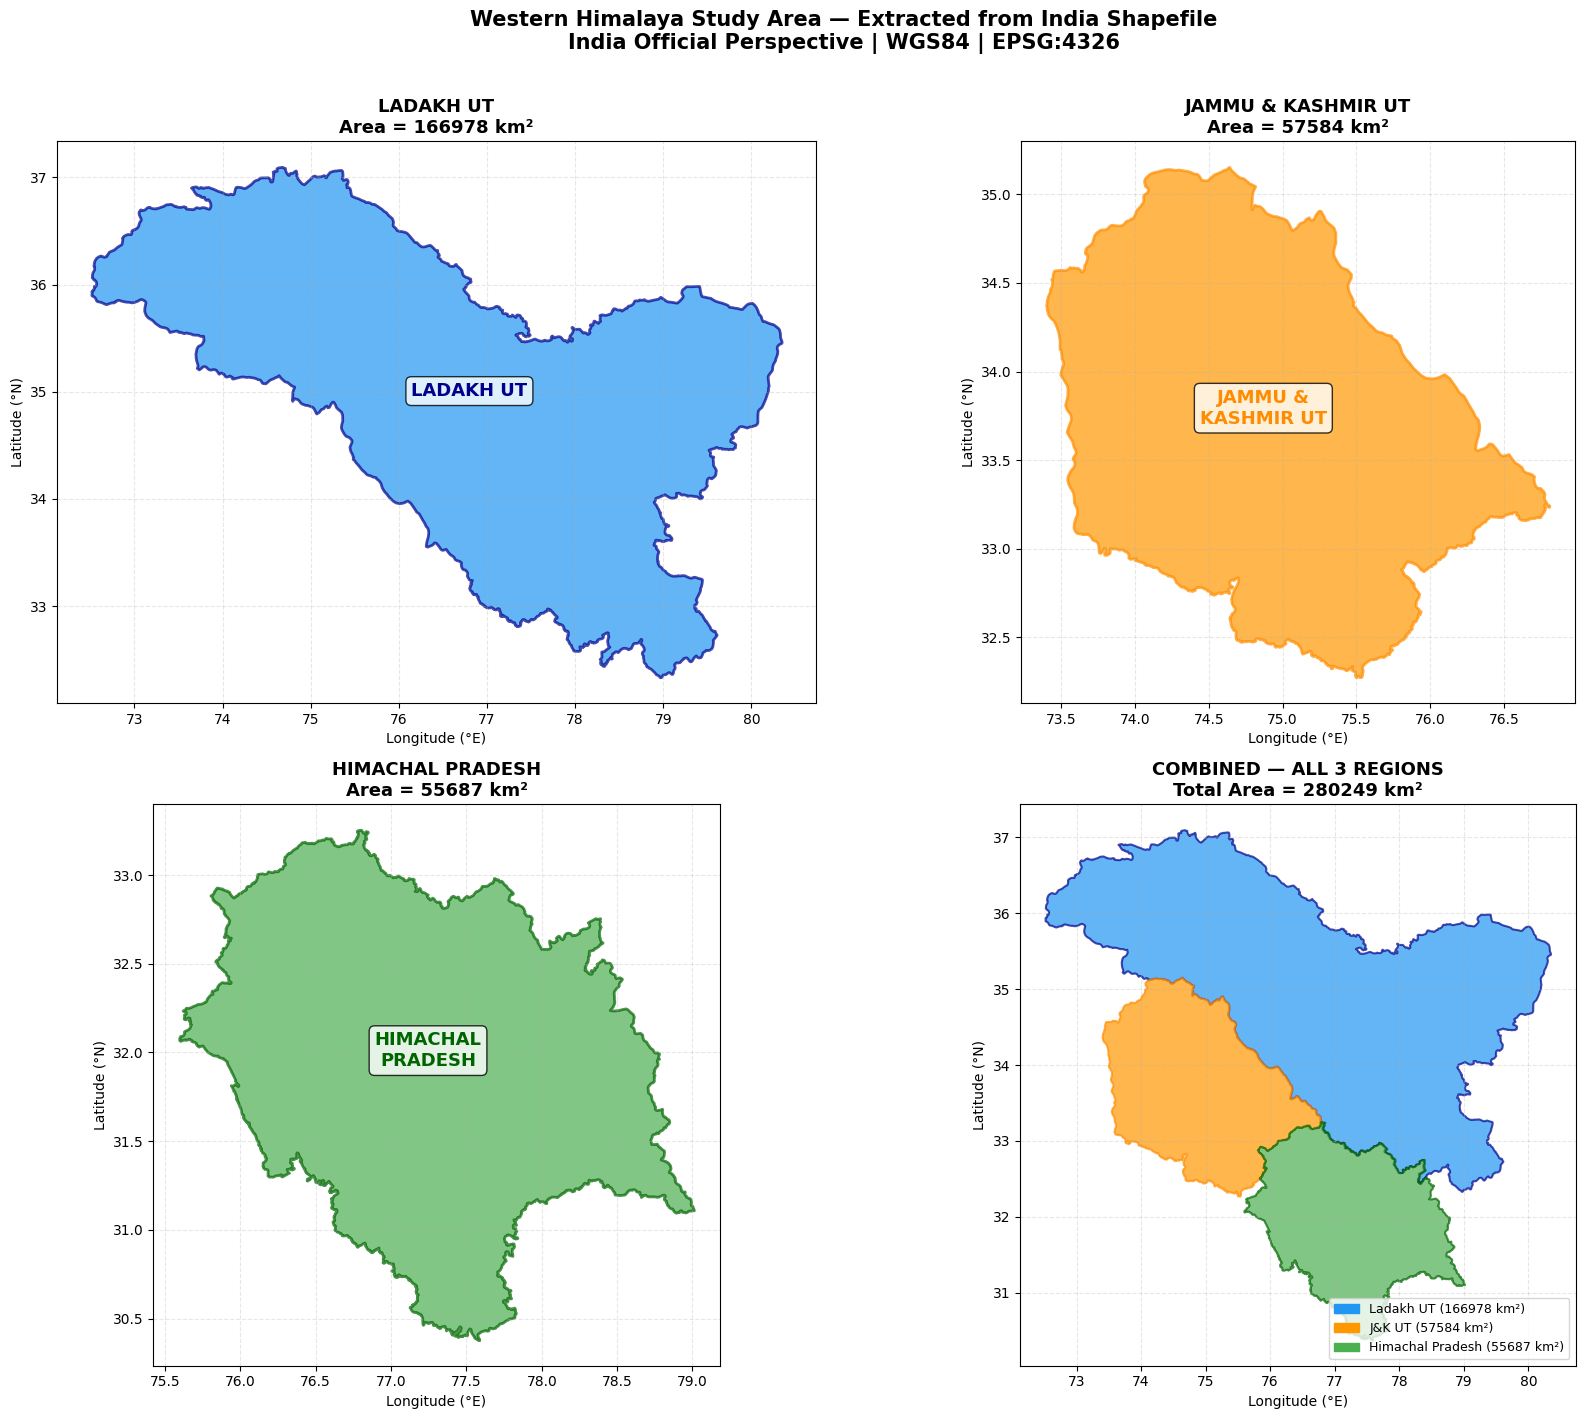

✅ Map saved to Drive


In [9]:
# ============================================================
# CELL 9: VISUALIZE ALL 3 + COMBINED
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ---- Colors ----
COLOR_LADAKH = '#2196F3'    # Blue
COLOR_JK     = '#FF9800'    # Orange
COLOR_HP     = '#4CAF50'    # Green

# ============================================================
# PLOT 1: LADAKH
# ============================================================
ax1 = axes[0][0]
if len(ladakh) > 0:
    ladakh.plot(ax=ax1,
                color=COLOR_LADAKH,
                edgecolor='darkblue',
                linewidth=2,
                alpha=0.7)
    cx = ladakh.geometry.centroid.x.values[0]
    cy = ladakh.geometry.centroid.y.values[0]
    ax1.annotate('LADAKH UT',
                 xy=(cx, cy),
                 fontsize=13,
                 fontweight='bold',
                 ha='center',
                 color='darkblue',
                 bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white',
                          alpha=0.8))
    area_l = (ladakh.to_crs('EPSG:32643')
              .geometry.area.sum()/1e6)
    ax1.set_title(f'LADAKH UT\nArea = {area_l:.0f} km²',
                  fontweight='bold', fontsize=13)
else:
    ax1.set_title('LADAKH — NOT FOUND ❌',
                  color='red', fontsize=13)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlabel('Longitude (°E)', fontsize=10)
ax1.set_ylabel('Latitude (°N)', fontsize=10)

# ============================================================
# PLOT 2: JAMMU & KASHMIR
# ============================================================
ax2 = axes[0][1]
if len(jk) > 0:
    jk.plot(ax=ax2,
            color=COLOR_JK,
            edgecolor='darkorange',
            linewidth=2,
            alpha=0.7)
    cx = jk.geometry.centroid.x.values[0]
    cy = jk.geometry.centroid.y.values[0]
    ax2.annotate('JAMMU &\nKASHMIR UT',
                 xy=(cx, cy),
                 fontsize=13,
                 fontweight='bold',
                 ha='center',
                 color='darkorange',
                 bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white',
                          alpha=0.8))
    area_jk = (jk.to_crs('EPSG:32643')
               .geometry.area.sum()/1e6)
    ax2.set_title(f'JAMMU & KASHMIR UT\n'
                  f'Area = {area_jk:.0f} km²',
                  fontweight='bold', fontsize=13)
else:
    ax2.set_title('J&K — NOT FOUND ❌',
                  color='red', fontsize=13)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlabel('Longitude (°E)', fontsize=10)
ax2.set_ylabel('Latitude (°N)', fontsize=10)

# ============================================================
# PLOT 3: HIMACHAL PRADESH
# ============================================================
ax3 = axes[1][0]
if len(hp) > 0:
    hp.plot(ax=ax3,
            color=COLOR_HP,
            edgecolor='darkgreen',
            linewidth=2,
            alpha=0.7)
    cx = hp.geometry.centroid.x.values[0]
    cy = hp.geometry.centroid.y.values[0]
    ax3.annotate('HIMACHAL\nPRADESH',
                 xy=(cx, cy),
                 fontsize=13,
                 fontweight='bold',
                 ha='center',
                 color='darkgreen',
                 bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white',
                          alpha=0.8))
    area_hp = (hp.to_crs('EPSG:32643')
               .geometry.area.sum()/1e6)
    ax3.set_title(f'HIMACHAL PRADESH\n'
                  f'Area = {area_hp:.0f} km²',
                  fontweight='bold', fontsize=13)
else:
    ax3.set_title('HIMACHAL PRADESH — NOT FOUND ❌',
                  color='red', fontsize=13)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlabel('Longitude (°E)', fontsize=10)
ax3.set_ylabel('Latitude (°N)', fontsize=10)

# ============================================================
# PLOT 4: ALL 3 COMBINED
# ============================================================
ax4 = axes[1][1]
total = 0
patches_legend = []

if len(ladakh) > 0:
    ladakh.plot(ax=ax4,
                color=COLOR_LADAKH,
                edgecolor='darkblue',
                linewidth=1.5,
                alpha=0.7,
                label='Ladakh UT')
    area_l = (ladakh.to_crs('EPSG:32643')
              .geometry.area.sum()/1e6)
    total += area_l
    patches_legend.append(
        mpatches.Patch(color=COLOR_LADAKH,
                      label=f'Ladakh UT ({area_l:.0f} km²)'))

if len(jk) > 0:
    jk.plot(ax=ax4,
            color=COLOR_JK,
            edgecolor='darkorange',
            linewidth=1.5,
            alpha=0.7,
            label='J&K UT')
    area_jk = (jk.to_crs('EPSG:32643')
               .geometry.area.sum()/1e6)
    total += area_jk
    patches_legend.append(
        mpatches.Patch(color=COLOR_JK,
                      label=f'J&K UT ({area_jk:.0f} km²)'))

if len(hp) > 0:
    hp.plot(ax=ax4,
            color=COLOR_HP,
            edgecolor='darkgreen',
            linewidth=1.5,
            alpha=0.7,
            label='Himachal Pradesh')
    area_hp = (hp.to_crs('EPSG:32643')
               .geometry.area.sum()/1e6)
    total += area_hp
    patches_legend.append(
        mpatches.Patch(color=COLOR_HP,
                      label=f'Himachal Pradesh ({area_hp:.0f} km²)'))

ax4.set_title(f'COMBINED — ALL 3 REGIONS\n'
              f'Total Area = {total:.0f} km²',
              fontweight='bold', fontsize=13)
ax4.legend(handles=patches_legend,
           loc='lower right',
           fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlabel('Longitude (°E)', fontsize=10)
ax4.set_ylabel('Latitude (°N)', fontsize=10)

plt.suptitle(
    'Western Himalaya Study Area — Extracted from India Shapefile\n'
    'India Official Perspective | WGS84 | EPSG:4326',
    fontsize=15,
    fontweight='bold',
    y=1.01
)
plt.tight_layout()

# Save map
map_file = out + 'All_Regions_Map.png'
plt.savefig(map_file, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Map saved to Drive")

In [10]:
# ============================================================
# CELL 10: SAVE ALL INDIVIDUAL SHAPEFILES TO DRIVE
# ============================================================

def save_all_formats(gdf, name, folder):
    """Save SHP + GeoJSON + KML"""

    # Shapefile
    shp = folder + f'{name}.shp'
    gdf.to_file(shp, driver='ESRI Shapefile')
    print(f"  ✅ {name}.shp")

    # GeoJSON
    gjson = folder + f'{name}.geojson'
    gdf.to_file(gjson, driver='GeoJSON')
    print(f"  ✅ {name}.geojson")

    # KML
    kml = folder + f'{name}.kml'
    gdf.to_file(kml, driver='KML')
    print(f"  ✅ {name}.kml")

print("="*55)
print("SAVING ALL FILES TO GOOGLE DRIVE")
print("="*55)

# ---- LADAKH ----
if len(ladakh) > 0:
    os.makedirs(out + 'Ladakh/', exist_ok=True)
    print("\n📁 Saving LADAKH...")
    save_all_formats(ladakh, 'Ladakh_UT', out + 'Ladakh/')

# ---- J&K ----
if len(jk) > 0:
    os.makedirs(out + 'JammuKashmir/', exist_ok=True)
    print("\n📁 Saving JAMMU & KASHMIR...")
    save_all_formats(jk, 'JammuKashmir_UT',
                     out + 'JammuKashmir/')

# ---- HIMACHAL PRADESH ----
if len(hp) > 0:
    os.makedirs(out + 'HimachalPradesh/', exist_ok=True)
    print("\n📁 Saving HIMACHAL PRADESH...")
    save_all_formats(hp, 'HimachalPradesh',
                     out + 'HimachalPradesh/')

# ---- COMBINED ALL 3 ----
print("\n📁 Saving COMBINED (All 3 regions)...")
os.makedirs(out + 'Combined/', exist_ok=True)

all_parts = []
if len(ladakh) > 0: all_parts.append(ladakh)
if len(jk) > 0:     all_parts.append(jk)
if len(hp) > 0:     all_parts.append(hp)

if len(all_parts) > 0:
    combined = gpd.GeoDataFrame(
        pd.concat(all_parts, ignore_index=True),
        crs='EPSG:4326'
    )
    save_all_formats(combined,
                     'Western_Himalaya_Combined',
                     out + 'Combined/')

    # Also save dissolved (single polygon)
    dissolved = combined.dissolve().reset_index()
    dissolved['NAME'] = 'Western_Himalaya_Study_Area'
    save_all_formats(dissolved,
                     'Western_Himalaya_Dissolved',
                     out + 'Combined/')

print(f"\n✅ All files saved!")

SAVING ALL FILES TO GOOGLE DRIVE

📁 Saving LADAKH...
  ✅ Ladakh_UT.shp
  ✅ Ladakh_UT.geojson
  ✅ Ladakh_UT.kml

📁 Saving JAMMU & KASHMIR...
  ✅ JammuKashmir_UT.shp
  ✅ JammuKashmir_UT.geojson
  ✅ JammuKashmir_UT.kml

📁 Saving HIMACHAL PRADESH...
  ✅ HimachalPradesh.shp
  ✅ HimachalPradesh.geojson
  ✅ HimachalPradesh.kml

📁 Saving COMBINED (All 3 regions)...
  ✅ Western_Himalaya_Combined.shp
  ✅ Western_Himalaya_Combined.geojson
  ✅ Western_Himalaya_Combined.kml
  ✅ Western_Himalaya_Dissolved.shp


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NAME' to 'NAME_1'
  ogr_write(


  ✅ Western_Himalaya_Dissolved.geojson
  ✅ Western_Himalaya_Dissolved.kml

✅ All files saved!


script saved for future as well worked perfectly !